# This notebook plot annual mean MCS rain statistics on maps
## The monthly data is produced by: 
* PyFLEXTRKR-dev/Analysis/calc_tbpf_mcs_monthly_rainmap.py
## The climatology data is produced by:
* scripts/calc_mcs_rainmap_climo_from_monthly.py

In [1]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import copy, os
import colormaps as cmaps

In [2]:
# Name mapping (values are the display names for each dataset)
name_map = {
    'obs': 'IMERGv7',
    'm1': 'E3SM',
}

# Input filenames
rootdir1 = '/pscratch/sd/f/feng045/E3SM_polun/OBS/monthly/'
rootdir2 = '/pscratch/sd/f/feng045/E3SM_polun/E3SM_CTL/monthly/'
filenames = {
    'obs': os.path.join(rootdir1, 'mcs_rainmap_monthly_climo_200701_200712.nc'),
    'm1': os.path.join(rootdir2, 'mcs_rainmap_monthly_climo_200101_200112.nc'),
}

# Topography and Tb valid fraction files
topofile = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/era5_orography.nc'
maskfile = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/merg_valid_fraction_1998_2024.nc'

# Output figure directory
figdir = '/global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/pscratch/sd/f/feng045/E3SM_polun/OBS/monthly/mcs_rainmap_monthly_climo_200701_200712.nc: True
/pscratch/sd/f/feng045/E3SM_polun/E3SM_CTL/monthly/mcs_rainmap_monthly_climo_200101_200112.nc: True


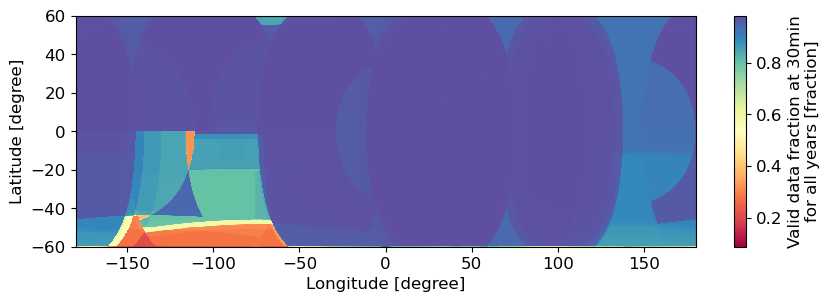

In [30]:
# Get missing value mask
dsm = xr.open_dataset(maskfile)
lon_mask = dsm.lon
lat_mask = dsm.lat
frac30 = dsm.fraction_30min_all

fig = plt.figure(figsize=(10,3),dpi=100)
frac30.plot(cmap='Spectral')

(1200, 3600)


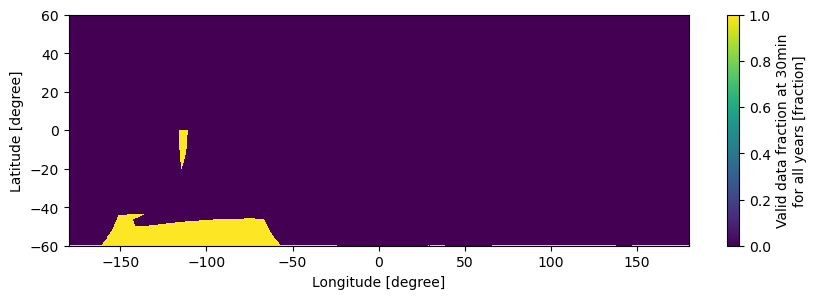

In [5]:
# Define missing data mask
mask_miss = frac30 < 0.75
print(mask_miss.shape)
fig = plt.figure(figsize=(10,3),dpi=100)
mask_miss.plot()

In [6]:
# Read topography and land fraction data
dstop = xr.open_dataset(topofile).squeeze()
ter = dstop.z.load() / 9.81  # Convert geopotential to meters
lon_ter = dstop.longitude.load()
lat_ter = dstop.latitude.load()
dstop

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 1979-01-01
Data variables:
    z          (latitude, longitude) float64 8MB -0.07519 -0.07519 ... 2.735e+04
Attributes:
    Conventions:  CF-1.6
    history:      2020-01-09 22:51:17 GMT by grib_to_netcdf-2.15.0: /opt/ecmw...

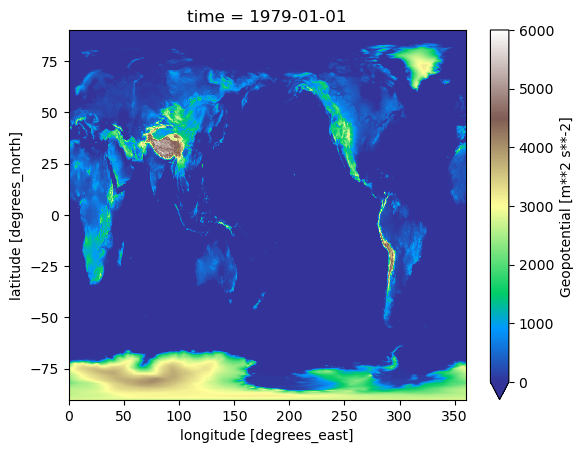

In [7]:
ter.plot(vmin=0, vmax=6000, cmap='terrain')

In [9]:
# Read IMERG data
lat_range = slice(-60, 60)
ds_obs = xr.open_dataset(filenames['obs']).sel(lat=lat_range)
lat_obs = ds_obs['lat'].load()
lon_obs = ds_obs['lon'].load()

# Roll IMERG longitude from [-180, 180) to [0, 360) to match E3SM's convention
n_roll = int((lon_obs < 0).sum())
ds_obs = ds_obs.roll(lon=-n_roll, roll_coords=True)
ds_obs

<xarray.Dataset> Size: 13MB
Dimensions:                          (time: 12, lat: 120, lon: 360)
Coordinates:
  * time                             (time) datetime64[ns] 96B 2000-01-01 ......
  * lat                              (lat) float64 960B -59.5 -58.5 ... 59.5
  * lon                              (lon) float64 3kB 0.0 1.0 2.0 ... -2.0 -1.0
    month                            (time) int64 96B ...
Data variables:
    precipitation                    (time, lat, lon) float32 2MB 0.3496 ... ...
    mcs_precipitation                (time, lat, lon) float32 2MB 0.07358 ......
    mcs_precipitation_frac           (time, lat, lon) float32 2MB 21.05 ... 7...
    mcs_precipitation_freq           (time, lat, lon) float32 2MB 0.8065 ... ...
    mcs_precipitation_intensity      (time, lat, lon) float32 2MB 0.3802 ... ...
    mcs_cloud_freq                   (time, lat, lon) float32 2MB 4.301 ... 1...
    precipitation_std                (lat, lon) float32 173kB 0.0 0.0 ... 0.0
    mcs_precipitation_std            (lat, lon) float32 173kB 0.0 0.0 ... 0.0
    mcs_precipitation_frac_std       (lat, lon) float32 173kB 0.0 0.0 ... 0.0
    mcs_precipitation_freq_std       (lat, lon) float32 173kB 0.0 0.0 ... 0.0
    mcs_precipitation_intensity_std  (lat, lon) float32 173kB 0.0 0.0 ... 0.0
    mcs_cloud_freq_std               (lat, lon) float32 173kB 0.0 0.0 ... 0.0
Attributes:
    title:       MCS precipitation climatology statistics
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    start_date:  2007-01
    end_date:    2007-12
    created_on:  2026-06-18T09:52:57.446601
    created_by:  /global/u1/f/feng045/program/e3sm_polun/scripts/calc_mcs_rai...

In [10]:
# Read E3SM data, subset latitude range to match IMERG
lat_range = slice(-60, 60)
ds_m1 = xr.open_dataset(filenames['m1']).sel(lat=lat_range)
lat_m1 = ds_m1['lat'].load()
lon_m1 = ds_m1['lon'].load()

# Replace IMERG's rolled lon coordinate with E3SM's lon (grid counts match; ignore the 0.5 deg offset)
ds_obs = ds_obs.assign_coords(lon=lon_m1)
# Latitudes are already identical between datasets; align lat coordinate for floating-point consistency
ds_m1 = ds_m1.assign_coords(lat=lat_obs)
ds_m1

<xarray.Dataset> Size: 13MB
Dimensions:                          (time: 12, lat: 120, lon: 360)
Coordinates:
  * time                             (time) datetime64[ns] 96B 2000-01-01 ......
  * lat                              (lat) float64 960B -59.5 -58.5 ... 59.5
  * lon                              (lon) float64 3kB 0.5 1.5 ... 358.5 359.5
    month                            (time) int64 96B ...
Data variables:
    precipitation                    (time, lat, lon) float32 2MB ...
    mcs_precipitation                (time, lat, lon) float32 2MB ...
    mcs_precipitation_frac           (time, lat, lon) float32 2MB ...
    mcs_precipitation_freq           (time, lat, lon) float32 2MB ...
    mcs_precipitation_intensity      (time, lat, lon) float32 2MB ...
    mcs_cloud_freq                   (time, lat, lon) float32 2MB ...
    precipitation_std                (lat, lon) float32 173kB ...
    mcs_precipitation_std            (lat, lon) float32 173kB ...
    mcs_precipitation_frac_std       (lat, lon) float32 173kB ...
    mcs_precipitation_freq_std       (lat, lon) float32 173kB ...
    mcs_precipitation_intensity_std  (lat, lon) float32 173kB ...
    mcs_cloud_freq_std               (lat, lon) float32 173kB ...
Attributes:
    title:       MCS precipitation climatology statistics
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    start_date:  2001-01
    end_date:    2001-12
    created_on:  2026-06-18T09:51:09.535798
    created_by:  /global/u1/f/feng045/program/e3sm_polun/scripts/calc_mcs_rai...

In [11]:
# Combine datasets into a single one for easier plotting
ds = xr.concat([ds_obs, ds_m1], dim="source", join='exact')
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
ds

<xarray.Dataset> Size: 27MB
Dimensions:                          (source: 2, time: 12, lat: 120, lon: 360)
Coordinates:
  * source                           (source) <U3 24B 'obs' 'm1'
  * time                             (time) datetime64[ns] 96B 2000-01-01 ......
  * lat                              (lat) float64 960B -59.5 -58.5 ... 59.5
  * lon                              (lon) float64 3kB 0.5 1.5 ... 358.5 359.5
    month                            (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    precipitation                    (source, time, lat, lon) float32 4MB 0.3...
    mcs_precipitation                (source, time, lat, lon) float32 4MB 0.0...
    mcs_precipitation_frac           (source, time, lat, lon) float32 4MB 21....
    mcs_precipitation_freq           (source, time, lat, lon) float32 4MB 0.8...
    mcs_precipitation_intensity      (source, time, lat, lon) float32 4MB 0.3...
    mcs_cloud_freq                   (source, time, lat, lon) float32 4MB 4.3...
    precipitation_std                (source, lat, lon) float32 346kB 0.0 ......
    mcs_precipitation_std            (source, lat, lon) float32 346kB 0.0 ......
    mcs_precipitation_frac_std       (source, lat, lon) float32 346kB 0.0 ......
    mcs_precipitation_freq_std       (source, lat, lon) float32 346kB 0.0 ......
    mcs_precipitation_intensity_std  (source, lat, lon) float32 346kB 0.0 ......
    mcs_cloud_freq_std               (source, lat, lon) float32 346kB 0.0 ......
Attributes:
    title:       MCS precipitation climatology statistics
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    start_date:  2007-01
    end_date:    2007-12
    created_on:  2026-06-18T09:52:57.446601
    created_by:  /global/u1/f/feng045/program/e3sm_polun/scripts/calc_mcs_rai...

In [12]:
# Annual mean 
tot_pcp_annual = ds['precipitation'].mean(dim='time').compute()
mcs_pcp_annual = ds['mcs_precipitation'].mean(dim='time').compute()
# MCS precipitation fraction
mcs_pcpfrac_annual = (100 * mcs_pcp_annual / tot_pcp_annual).where(tot_pcp_annual > 0).compute()
# MCS precipitaiton & cloud frequency
mcs_pcpfreq_annual = ds['mcs_precipitation_freq'].mean(dim='time').compute()
mcs_cldfreq_annual = ds['mcs_cloud_freq'].mean(dim='time').compute()

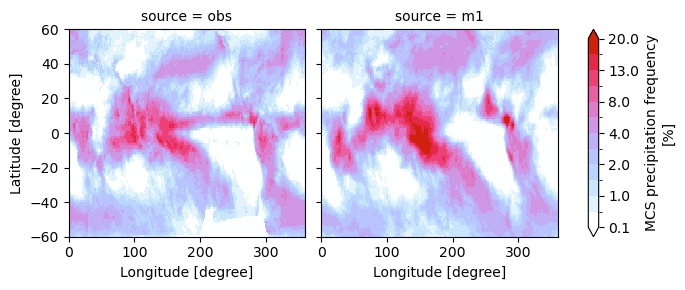

In [13]:
lev1 = [0.1,0.5,1,1.5,2,3,4,6,8,10,13,16,20]
cmap1 = cmaps.cet_l_wcmr
norm1 = colors.BoundaryNorm(boundaries=lev1, ncolors=cmap1.N)
mcs_pcpfreq_annual.plot(col='source', col_wrap=2, cmap=cmap1, norm=norm1)

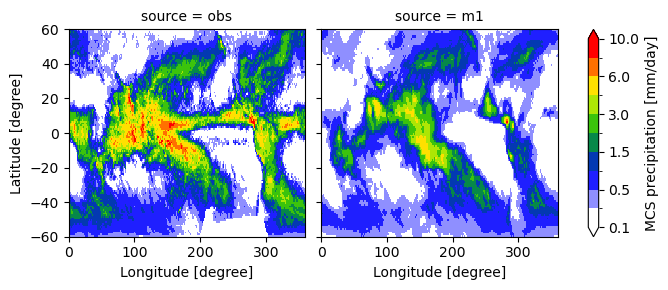

In [14]:
lev2 = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
cmap2 = cmaps.WhBlGrYeRe
norm2 = colors.BoundaryNorm(boundaries=lev2, ncolors=cmap2.N)
mcs_pcp_annual.plot(col='source', col_wrap=2, cmap=cmap2, norm=norm2)

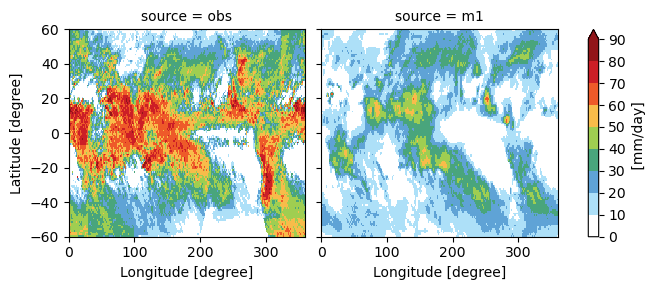

In [15]:
lev3 = np.arange(0, 91, 10)
cmap3 = cmaps.WhiteBlueGreenYellowRed
norm3 = colors.BoundaryNorm(boundaries=lev3, ncolors=cmap3.N)
mcs_pcpfrac_annual.plot(col='source', col_wrap=2, cmap=cmap3, norm=norm3)

In [16]:
# Seasonal mean 
tot_pcp_seasonal = ds['precipitation'].groupby('time.season').mean(dim='time').compute()
mcs_pcp_seasonal = ds['mcs_precipitation'].groupby('time.season').mean(dim='time').compute()
# MCS precipitation fraction
mcs_pcpfrac_seasonal = (100 * mcs_pcp_seasonal / tot_pcp_seasonal).where(tot_pcp_seasonal > 0).compute()
# MCS precipitaiton & cloud frequency
mcs_pcpfreq_seasonal = ds['mcs_precipitation_freq'].groupby('time.season').mean(dim='time').compute()
mcs_cldfreq_seasonal = ds['mcs_cloud_freq'].groupby('time.season').mean(dim='time').compute()

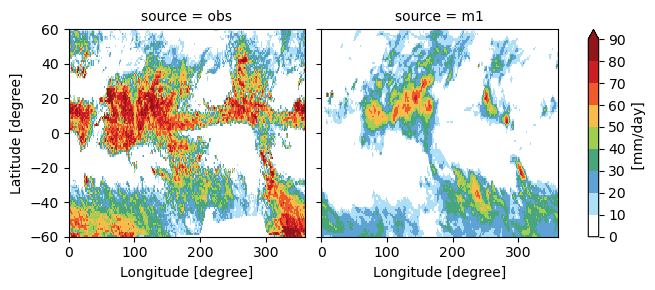

In [17]:
lev3 = np.arange(0, 91, 10)
cmap3 = cmaps.WhiteBlueGreenYellowRed
norm3 = colors.BoundaryNorm(boundaries=lev3, ncolors=cmap3.N)
mcs_pcpfrac_seasonal.sel(season='JJA').plot(col='source', col_wrap=2, cmap=cmap3, norm=norm3)

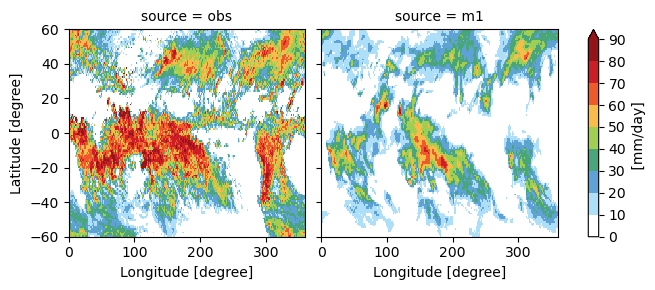

In [18]:
lev3 = np.arange(0, 91, 10)
cmap3 = cmaps.WhiteBlueGreenYellowRed
norm3 = colors.BoundaryNorm(boundaries=lev3, ncolors=cmap3.N)
mcs_pcpfrac_seasonal.sel(season='DJF').plot(col='source', col_wrap=2, cmap=cmap3, norm=norm3)

In [20]:
# # lev1 = [0.1,0.5,1,1.5,2,3,4,6,8]
# lev1 = [0.1,0.2,0.4,0.7,1,1.5,2,2.5,3]
# # lev1 = np.arange(0.2, 3.01, 0.2)
# cmap1 = cmaps.cet_l_wcmr
# norm1 = colors.BoundaryNorm(boundaries=lev1, ncolors=cmap1.N)
# ds['mcs_precipitation_freq_std'].plot(col='source', col_wrap=2, cmap=cmap1, norm=norm1)

In [21]:
# lev2 = [0.2,0.5,1,1.5,2,2.5,3,4,6,8]
# cmap2 = cmaps.WhBlGrYeRe
# norm2 = colors.BoundaryNorm(boundaries=lev2, ncolors=cmap2.N)
# ds['mcs_precipitation_std'].plot(col='source', col_wrap=2, cmap=cmap2, norm=norm2)

In [22]:
# lev3 = np.arange(0, 32.1, 4)
# cmap3 = cmaps.WhiteBlueGreenYellowRed
# norm3 = colors.BoundaryNorm(boundaries=lev3, ncolors=cmap3.N)
# ds['mcs_precipitation_frac_std'].plot(col='source', col_wrap=2, cmap=cmap3, norm=norm3)

## Function to make N x M maps (with 1 colorbar for each row)

In [31]:
def plot_nxm_maps_1colorbar(nrow, ncol, data_arrays, lon_ter, lat_ter,
                            projection=None, central_lon=225, lat_range=None,
                            titles=None, levels=None, colormaps=None, cblabels=None, cbticks=None,
                            min_thresh=None, oob_colors=None,
                            lon_label=False, lat_label=False,
                            terrain_data=None, terrain_levels=None, 
                            mask=None, show_mask=None,
                            wspace=None, hspace=None, figsize=None, fontsize=None, 
                            figtitle=None, figname=None, dpi=200):
    """
    Plot N x M maps with Cartopy projection and ONE colorbar per row.
    
    Parameters:
    -----------
    nrow, ncol : int
        Number of rows and columns
    data_arrays : list of lists
        2D list of xarray DataArrays [nrow][ncol]
    lon_ter, lat_ter : arrays
        HEALPix longitude and latitude coordinates for terrain data
    projection : cartopy projection
        Default: Robinson with central_lon
    central_lon : float
        Central longitude for projection (default: 225)
    lat_range : tuple
        (lat_min, lat_max) to clip display, e.g., (-60, 60)
    titles : list of lists
        2D list of subplot titles [nrow][ncol]
    levels : list of lists
        Contour levels per row [nrow][levels] - same levels for all columns in a row
    colormaps : list
        Colormap per row [nrow] - same colormap for all columns in a row
    cblabels : list
        Colorbar label per row [nrow]
    cbticks : list of lists
        Colorbar tick locations per row [nrow][ticks]
    min_thresh : float
        Minimum threshold to mask data
    oob_colors : dict or list of dicts
        Out-of-bounds colors per row {'over': color, 'under': color}
    lon_label : bool or list
        Show longitude labels on gridlines. Can be single bool or list matching data_arrays structure
    lat_label : bool or list
    terrain_data : xarray DataArray
        Terrain elevation data to overplot as contours (e.g., dstop.ELEV)
    terrain_levels : list or single value
        Terrain contour levels to plot in gray. If single value, plots one contour level
    wspace, hspace : float
        Spacing between subplots
    figsize : tuple
        Figure size (width, height)
    fontsize : int
        Font size for labels
    figtitle : str
        Overall figure title
    figname : str
        Output filename
    dpi : int
        DPI for saved figure
    """
    
    # Handle case where oob_colors might be a single dict or list of dicts
    def ensure_row_format(param, nrow):
        if param is None:
            return [None] * nrow
        elif isinstance(param, dict):
            # Single dict, apply to all rows
            return [param] * nrow
        elif isinstance(param, list):
            if len(param) == nrow:
                return param
            else:
                # Single list, apply to all rows
                return [param] * nrow
        return param
    
    # Ensure parameters are in row format
    oob_colors = ensure_row_format(oob_colors, nrow)
    if not isinstance(colormaps, list):
        colormaps = [colormaps] * nrow
    if not isinstance(cblabels, list):
        cblabels = [cblabels] * nrow
    
    # Handle lon_label and lat_label - convert to 2D list matching data_arrays structure
    def ensure_grid_bool_format(param, nrow, ncol):
        if isinstance(param, bool):
            # Single bool, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                return [[False for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a 2D list
                return param
            elif isinstance(param[0], bool):
                # 1D list of bools - check if it matches nrow or ncol
                if len(param) == nrow:
                    # One value per row, apply to all columns in that row
                    return [[param[r] for _ in range(ncol)] for r in range(nrow)]
                elif len(param) == ncol:
                    # One value per column, apply to all rows in that column
                    return [[param[c] for c in range(ncol)] for _ in range(nrow)]
                else:
                    # Doesn't match, default to False
                    return [[False for _ in range(ncol)] for _ in range(nrow)]
        return [[False for _ in range(ncol)] for _ in range(nrow)]
    # Handle terrain_levels - convert to list if single value
    if terrain_levels is not None:
        if not isinstance(terrain_levels, list):
            terrain_levels = [terrain_levels]
    
    # Set default projection if not provided
    if projection is None:
        projection = ccrs.Robinson(central_longitude=central_lon)
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.size'] = fontsize
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    
    fig = plt.figure(figsize=figsize, dpi=100)
    
    # Main GridSpec: nrow rows, 2 columns (maps | colorbars)
    gs_main = gridspec.GridSpec(nrow, 2, figure=fig, 
                                width_ratios=[1, 0.01], wspace=0.02, hspace=hspace)
    
    # Loop over each row
    for row in range(nrow):
        # Create GridSpecFromSubplotSpec for maps in this row
        gs_maps = gridspec.GridSpecFromSubplotSpec(1, ncol, subplot_spec=gs_main[row, 0],
                                                    wspace=wspace, hspace=0.)
        
        # Track the last valid plot for colorbar
        cf1 = None
        
        # Loop over columns in this row
        for col in range(ncol):
            # Get data for this panel
            Var = data_arrays[row][col]
            lon = data_arrays[row][col].lon
            lat = data_arrays[row][col].lat
            
            if Var is not None:
                # Create map subplot with projection
                ax = plt.subplot(gs_maps[col], projection=projection)
                ax.set_global()  # Render full global map first
                ax.set_aspect('auto', adjustable=None)
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Setup colormap (same for all columns in this row)
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row]))
                # Set out-of-bounds colors
                if oob_colors[row] is not None:
                    cmap.set_over(oob_colors[row]['over'])
                    cmap.set_under(oob_colors[row]['under'])
                
                # Create color normalization (same for all columns in this row)
                norm = colors.BoundaryNorm(boundaries=levels[row], ncolors=cmap.N)
                
                # Plot data with pcolormesh
                cf1 = ax.pcolormesh(lon, lat, Var, shading='auto', norm=norm, cmap=cmap, transform=data_proj, zorder=2)

                # Add land boundaries
                ax.add_feature(land, facecolor='none', edgecolor='k', linewidth=0.5, zorder=3)

                # Fill missing IR data region
                if (mask is not None):
                    if show_mask[row][col]:
                        cmap_zmask = mpl.colors.ListedColormap(['white','lightgray','lightgray'])
                        norm_zmask = mpl.colors.BoundaryNorm(np.arange(0,2.1,1), cmap_zmask.N)
                        Zm = np.ma.masked_where(mask == False, mask)
                        cm = ax.pcolormesh(lon_mask, lat_mask, Zm, cmap=cmap_zmask, norm=norm_zmask, transform=ccrs.PlateCarree(), zorder=2)
                        ax.text(-115, -54, 'Missing Data', color='k', ha='center', va='center', transform=data_proj, zorder=3)

                # Add terrain contours if provided
                if terrain_data is not None and terrain_levels is not None:
                    cs = ax.contour(lon_ter, lat_ter, ter, levels=terrain_levels, 
                                colors='dimgray', linewidths=0.8, transform=data_proj, zorder=3)
                
                # Add gridlines with optional labels
                gl = ax.gridlines(draw_labels=lon_label[row][col] or lat_label[row][col], 
                                 linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
                               
                # Set latitude range if provided
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = projection.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = projection.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Configure which labels to show
                if lon_label[row][col] or lat_label[row][col]:
                    gl.top_labels = False
                    gl.right_labels = False
                    gl.bottom_labels = lon_label[row][col]
                    gl.left_labels = lat_label[row][col]
                    gl.xlabel_style = {'size': fontsize-2}
                    gl.ylabel_style = {'size': fontsize-2}
                
                # Add title
                if titles is not None and titles[row][col] is not None:
                    ax.set_title(titles[row][col], loc='center', fontsize=fontsize)
        
        # Add ONE colorbar for this row (on the right)
        if cf1 is not None:
            cax = plt.subplot(gs_main[row, 1])
            cbar = plt.colorbar(cf1, cax=cax, label=cblabels[row], 
                               ticks=cbticks[row], orientation='vertical', extend='both')
    
    # Add overall figure title
    if figtitle:
        fig.suptitle(figtitle, y=0.98, fontweight='bold', fontsize=fontsize+2)
    
    # Save figure
    if figname:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [26]:
# # Check if "IMERG" is in the source values to determine whether to show missing data mask
# source_values = list(name_map.values())
# show_mask_obs = True if "IMERG" in source_values else False
# show_mask_obs
# name_map.values()
name_map['obs']

'IMERGv7'

In [28]:
# show_mask_obs
list(name_map.values())

['IMERGv7', 'E3SM']

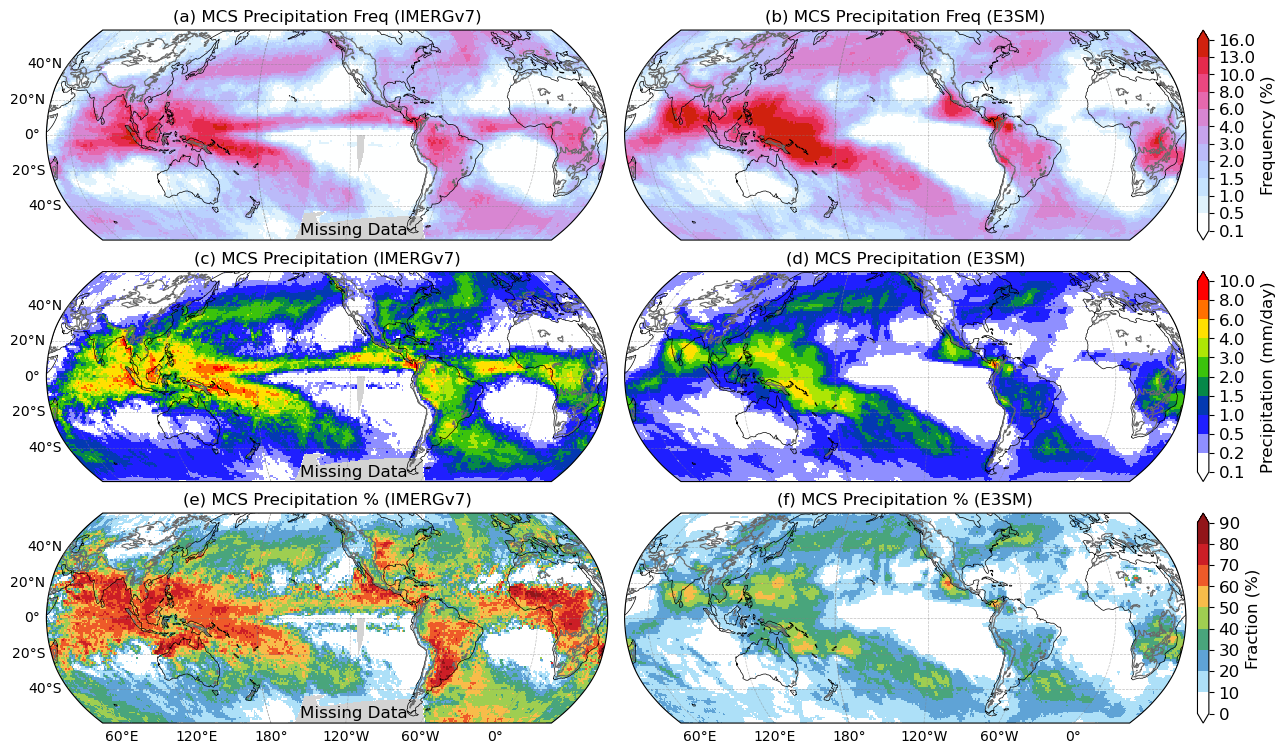

In [32]:
# Setup data arrays for plotting with 1 colorbar per row (3x2 grid)
# Row 1: MCS precipitation frequency, Row 2: MCS precipitation, Row 3: MCS precipitation fraction
data_arrays = [
    [mcs_pcpfreq_annual.sel(source='obs'), mcs_pcpfreq_annual.sel(source='m1')],
    [mcs_pcp_annual.sel(source='obs'), mcs_pcp_annual.sel(source='m1')],
    [mcs_pcpfrac_annual.sel(source='obs'), mcs_pcpfrac_annual.sel(source='m1')],
]

titles = [
    [f"(a) MCS Precipitation Freq ({name_map['obs']})", f"(b) MCS Precipitation Freq ({name_map['m1']})"],
    [f"(c) MCS Precipitation ({name_map['obs']})", f"(d) MCS Precipitation ({name_map['m1']})"],
    [f"(e) MCS Precipitation % ({name_map['obs']})", f"(f) MCS Precipitation % ({name_map['m1']})"],
]

# Setup grid parameters
nrow = len(data_arrays)
ncol = len(data_arrays[0])
figwidth = 15
height_ratio_per_panel = 0.4
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
wspace = 0.03
hspace = 0.15

# Row 1
lev1 = [0.1,0.5,1,1.5,2,3,4,6,8,10,13,16]
cmap1 = cmaps.cet_l_wcmr
cblabel1 = f'Frequency (%)'

# Row 2
lev2 = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
cmap2 = cmaps.WhBlGrYeRe
cblabel2 = f'Precipitation (mm/day)'

# Row 3
lev3 = np.arange(0, 91, 10)
cmap3 = cmaps.WhiteBlueGreenYellowRed
cblabel3 = f'Fraction (%)'

# Organize as lists (one per row)
levels = [lev1, lev2, lev3]
colormaps = [cmap1, cmap2, cmap3]
cblabels = [cblabel1, cblabel2, cblabel3]
cbticks = [lev1, lev2, lev3]
oob_colors = [None, None, None]

figtitle = None
figname = f"{figdir}maps_mcs_pcpfreq_pcp_pcpfrac_{name_map['obs']}_{name_map['m1']}_annual.png"

# Setup projection and latitude range
projection = ccrs.Robinson(central_longitude=225)
# lat_range = (-60., 60.)
lat_range = (-59.9, 59.9)

# Check if "IMERG" is in the source values to determine whether to show missing data mask
source_values = list(name_map.values())
show_mask_obs = True if "IMERGv7" in source_values else False

# Configure gridline labels: show labels on leftmost column and bottom row
lat_label = [[True, False],
             [True, False],
             [True, False]]
lon_label = [[False, False],
             [False, False],
             [True, True]]
show_mask = [[show_mask_obs, False],
             [show_mask_obs, False],
             [show_mask_obs, False]]

# Optional: Add terrain contours (e.g., at 1500m elevation)
terrain_levels = [1000,10000]  # Set to None to disable terrain contours

# Plot figure with 1 colorbar per row
fig = plot_nxm_maps_1colorbar(nrow, ncol, data_arrays, lon_ter, lat_ter,
                              projection=projection, lat_range=lat_range,
                              titles=titles, levels=levels, colormaps=colormaps, 
                              cblabels=cblabels, cbticks=cbticks,
                              min_thresh=None, oob_colors=oob_colors,
                              lon_label=lon_label, lat_label=lat_label,
                              wspace=wspace, hspace=hspace, figsize=figsize, fontsize=fontsize,
                              terrain_data=ter, terrain_levels=terrain_levels, mask=mask_miss, show_mask=show_mask,   
                              figtitle=figtitle, figname=figname, dpi=300)

In [ ]:
# # Setup data arrays for plotting with 1 colorbar per row (3x2 grid)
# # Row 1: MCS precipitation frequency STD, Row 2: MCS precipitation STD, Row 3: MCS precipitation fraction STD
# data_arrays = [
#     [ds.mcs_precipitation_freq_std.sel(source='obs'), ds.mcs_precipitation_freq_std.sel(source='m1')],
#     [ds.mcs_precipitation_std.sel(source='obs'), ds.mcs_precipitation_std.sel(source='m1')],
#     [ds.mcs_precipitation_frac_std.sel(source='obs'), ds.mcs_precipitation_frac_std.sel(source='m1')],
# ]

# titles = [
#     [f"(a) MCS Precipitation Freq STD ({name_map['obs']})", f"(b) MCS Precipitation Freq STD ({name_map['m1']})"],
#     [f"(c) MCS Precipitation STD ({name_map['obs']})", f"(d) MCS Precipitation STD ({name_map['m1']})"],
#     [f"(e) MCS Precipitation % STD ({name_map['obs']})", f"(f) MCS Precipitation % STD ({name_map['m1']})"],
# ]

# # Setup grid parameters
# nrow = len(data_arrays)
# ncol = len(data_arrays[0])
# figwidth = 15
# height_ratio_per_panel = 0.4
# figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
# figsize = [figwidth, figheight]
# fontsize = 12
# wspace = 0.03
# hspace = 0.15

# # Row 1
# # lev1 = [0.1,0.2,0.6,1,1.5,2,2.5,3,4,6]
# lev1 = [0.1,0.2,0.4,0.7,1,1.5,2,2.5,3]
# cmap1 = cmaps.cet_l_wcmr
# cblabel1 = f'Frequency (%)'

# # Row 2
# lev2 = [0.2,0.5,1,1.5,2,2.5,3,4,6,8]
# cmap2 = cmaps.WhBlGrYeRe
# cblabel2 = f'Precipitation (mm/day)'

# # Row 3
# lev3 = np.arange(0, 32.1, 4)
# cmap3 = cmaps.WhiteBlueGreenYellowRed
# cblabel3 = f'Fraction (%)'

# # Organize as lists (one per row)
# levels = [lev1, lev2, lev3]
# colormaps = [cmap1, cmap2, cmap3]
# cblabels = [cblabel1, cblabel2, cblabel3]
# cbticks = [lev1, lev2, lev3]
# oob_colors = [None, None, None]

# figtitle = None
# figname = f"{figdir}maps_mcs_pcpfreq_pcp_pcpfrac_STD_{name_map['obs']}_{name_map['m1']}_annual.png"

# # Plot figure with 1 colorbar per row
# fig = plot_nxm_maps_1colorbar(nrow, ncol, data_arrays, lon_ter, lat_ter,
#                               projection=projection, lat_range=lat_range,
#                               titles=titles, levels=levels, colormaps=colormaps, 
#                               cblabels=cblabels, cbticks=cbticks,
#                               min_thresh=None, oob_colors=oob_colors,
#                               lon_label=lon_label, lat_label=lat_label,
#                               wspace=wspace, hspace=hspace, figsize=figsize, fontsize=fontsize,
#                               terrain_data=ter, terrain_levels=terrain_levels, mask=mask_miss, show_mask=show_mask,   
#                               figtitle=figtitle, figname=figname, dpi=300)

In [33]:
# Row 1
lev1 = [0.1,0.5,1,1.5,2,3,4,6,8,10]
cmap1 = cmaps.cet_l_wcmr
cblabel1 = f'Frequency (%)'

# Row 2
lev2 = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
cmap2 = cmaps.WhBlGrYeRe
cblabel2 = f'Precipitation (mm/day)'

# Row 3
lev3 = np.arange(0, 91, 10)
cmap3 = cmaps.WhiteBlueGreenYellowRed
cblabel3 = f'Fraction (%)'

# Organize as lists (one per row)
levels = [lev1, lev2, lev3]
colormaps = [cmap1, cmap2, cmap3]
cblabels = [cblabel1, cblabel2, cblabel3]
cbticks = [lev1, lev2, lev3]
oob_colors = [None, None, None]

# seasons = ['JJA']
seasons = ['DJF', 'MAM', 'JJA', 'SON']
for season in seasons:
    # Setup data arrays for plotting with 1 colorbar per row (3x2 grid)
    # Row 1: MCS precipitation frequency, Row 2: MCS precipitation, Row 3: MCS precipitation fraction
    data_arrays = [
        [mcs_pcpfreq_seasonal.sel(source='obs', season=season), mcs_pcpfreq_seasonal.sel(source='m1', season=season)],
        [mcs_pcp_seasonal.sel(source='obs', season=season), mcs_pcp_seasonal.sel(source='m1', season=season)],
        [mcs_pcpfrac_seasonal.sel(source='obs', season=season), mcs_pcpfrac_seasonal.sel(source='m1', season=season)],
    ]
    titles = [
        [f"(a) {season} MCS Precipitation Freq ({name_map['obs']})", f"(b) {season} MCS Precipitation Freq ({name_map['m1']})"],
        [f"(c) {season} MCS Precipitation ({name_map['obs']})", f"(d) {season} MCS Precipitation ({name_map['m1']})"],
        [f"(e) {season} MCS Precipitation % ({name_map['obs']})", f"(f) {season} MCS Precipitation % ({name_map['m1']})"],
    ]
    figtitle = None
    figname = f'{figdir}maps_mcs_pcpfreq_pcp_pcpfrac_{name_map["obs"]}_{name_map["m1"]}_{season}.png'

    # Plot figure with 1 colorbar per row
    fig = plot_nxm_maps_1colorbar(nrow, ncol, data_arrays, lon_ter, lat_ter,
                                projection=projection, lat_range=lat_range,
                                titles=titles, levels=levels, colormaps=colormaps, 
                                cblabels=cblabels, cbticks=cbticks,
                                min_thresh=None, oob_colors=oob_colors,
                                lon_label=lon_label, lat_label=lat_label,
                                wspace=wspace, hspace=hspace, figsize=figsize, fontsize=fontsize,
                                terrain_data=ter, terrain_levels=terrain_levels, mask=mask_miss, show_mask=show_mask,   
                                figtitle=figtitle, figname=figname, dpi=300)
    plt.close(fig)
    print(f'Saved figure: {figname}')

Saved figure: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/maps_mcs_pcpfreq_pcp_pcpfrac_IMERGv7_E3SM_DJF.png
Saved figure: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/maps_mcs_pcpfreq_pcp_pcpfrac_IMERGv7_E3SM_MAM.png
Saved figure: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/maps_mcs_pcpfreq_pcp_pcpfrac_IMERGv7_E3SM_JJA.png
Saved figure: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/maps_mcs_pcpfreq_pcp_pcpfrac_IMERGv7_E3SM_SON.png
